28


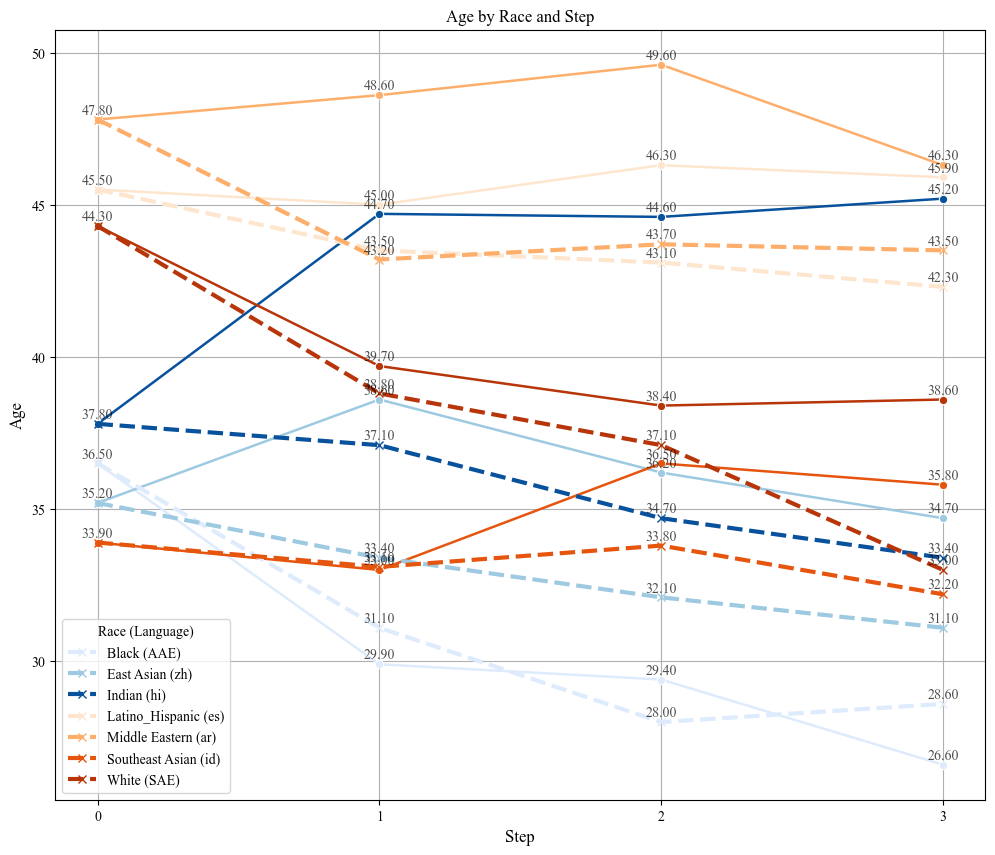

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取第一个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data_1 = pd.read_csv(file_path_1)

# 读取第二个数据文件
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data_2 = pd.read_csv(file_path_2)

# 计算每个递进层次下同一个种族的颜值打分平均值
mean_scores_1 = data_1.groupby(['Step', 'race']).agg({'Age': 'mean'}).reset_index()
mean_scores_2 = data_2.groupby(['Step', 'race']).agg({'Age': 'mean'}).reset_index()

# 创建种族和语言的对应关系
race_language_mapping = {
    'White': 'SAE',
    'Black': 'AAE',
    'Middle Eastern': 'ar',
    'Indian': 'hi',
    'Southeast Asian': 'id',
    'Latino_Hispanic': 'es',
    'East Asian': 'zh'
}

# 添加语言列
mean_scores_1['Language'] = mean_scores_1['race'].map(race_language_mapping)
mean_scores_2['Language'] = mean_scores_2['race'].map(race_language_mapping)
cmap = plt.get_cmap('tab20c')
#color = [cmap(i) for i in range(0, 20, 2)][:7]
color = ['#021b7e', '#9fa3ae', '#8fdbfb', '#e6520a', '#ccbae0', '#b3102b', '#9770b6']
color = ['#ece644', '#efab6d', '#7f7db5', '#a5ce9d', '#08519c', '#a2c8dd', ]
color=['#deebfc', '#9ecae1', '#08519c','#fee6ce', '#fdae6b', '#e6550d','#b73508'] 
# 绘图
plt.figure(figsize=(12, 10))

# 绘制第一个数据集
sns.lineplot(data=mean_scores_1, x='Step', y='Age', hue='race', marker='o', linestyle='-', palette=color, legend=False,linewidth=1.8)

# 绘制第二个数据集
for race in mean_scores_2['race'].unique():
    subset = mean_scores_2[mean_scores_2['race'] == race]
    plt.plot(subset['Step'], subset['Age'], marker='x', linestyle='--', color=sns.color_palette(color)[list(mean_scores_1['race'].unique()).index(race)], label=f"{race} ({subset['Language'].iloc[0]})",linewidth=3)

# 添加每个点的数值标签，稍微调整位置
for i in range(len(mean_scores_1)):
    plt.text(mean_scores_1['Step'][i], mean_scores_1['Age'][i] + 0.08,
             f"{mean_scores_1['Age'][i]:.2f}", 
             fontsize=10, ha='center', va='bottom', alpha=0.7)
print(len(mean_scores_2))
for i in range(7,28):
    plt.text(mean_scores_2['Step'][i], mean_scores_2['Age'][i] + 0.08,
             f"{mean_scores_2['Age'][i]:.2f}", 
             fontsize=10, ha='center', va='bottom', alpha=0.7)

# 设置图例格式为“种族（语言）”，并将图例移到右侧
plt.legend(title='Race (Language)', loc='lower left', bbox_to_anchor=(0, 0))

plt.title('Age by Race and Step')
plt.xlabel('Step',fontsize=12)
plt.ylabel('Age',fontsize=12)
plt.xticks([0, 1, 2, 3])  # 确保只显示0, 1, 2, 3
plt.grid()
plt.show()


In [11]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0、1、2、3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 计算每个步骤的平均数
        mean_values = subset.groupby('Step')['Age'].mean().reset_index()
        
        # 保留仅包含 Step 0、1、2、3 的数据
        step_subset = subset[subset['Step'].isin([0, 1, 2, 3])]
        
        if step_subset['Step'].nunique() >= 2:  # 如果有两个或更多 Step
            # 对每对步骤之间进行 Kruskal-Wallis H 检验
            steps = [0, 1, 2, 3]
            for i in range(len(steps)):
                for j in range(i + 1, len(steps)):
                    step_i = steps[i]
                    step_j = steps[j]
                    
                    # 筛选步骤数据
                    step_i_data = step_subset[step_subset['Step'] == step_i]['Age']
                    step_j_data = step_subset[step_subset['Step'] == step_j]['Age']
                    
                    # 如果两个步骤都有数据，则进行检验
                    if len(step_i_data) > 0 and len(step_j_data) > 0:
                        kruskal_stat, p_value = kruskal(step_i_data, step_j_data)
                        print(f"\nKruskal-Wallis H Test for {race_group} (Step {step_i} vs Step {step_j}):")
                        print(f"H-statistic: {kruskal_stat}, p-value: {p_value}")
                        
                        # 如果有显著性差异，进行 Dunn's Test 事后检验
                        if p_value < 0.05:
                            dunn_test = sp.posthoc_dunn(step_subset, val_col='Age', group_col='Step', p_adjust='bonferroni')
                            print(f"\nDunn's Test for {race_group} (Step {step_i} vs Step {step_j}):")
                            print(dunn_test)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 2):
H-statistic: 0.11606334841629398, p-value: 0.7333439595749913

Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 3):
H-statistic: 0.022978080120942896, p-value: 0.8795140882977863

Kruskal-Wallis H Test for Middle Eastern (Step 2 vs Step 3):
H-statistic: 0.414102564102556, p-value: 0.5198945163559406

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 2):
H-statistic: 0.36654107008289816, p-value: 0.5448957446685587

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 3):
H-statistic: 0.8272108843537442, p-value: 0.3630802727156893

Kruskal-Wallis H Test for East Asian (Step 2 vs Step 3):
H-statistic: 0.465658093797273, p-value: 0.49499145939457045

Kruskal-Wallis H Test for Black (Step 1 vs Step 2):
H-statistic: 0.012886209495095101, p-value: 0.9096203362443118

Kruskal-Wallis H Test for Black (Step 1 vs Step 3):
H-statistic: 0.7579939668174869, p-value: 0.38395703557389194

Kruskal

In [10]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0、1、2、3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 对 Step 0、1、2、3 进行中位数替换
        median_values = subset.groupby('Step')['Age'].median().reset_index()
        
        # 保留仅包含 Step 0、1、2、3 的数据
        step_subset = subset[subset['Step'].isin([0, 1, 2, 3])]
        
        if step_subset['Step'].nunique() >= 2:  # 如果有两个或更多 Step
            # 对每对步骤之间进行 Kruskal-Wallis H 检验
            steps = [0, 1, 2, 3]
            for i in range(len(steps)):
                for j in range(i + 1, len(steps)):
                    step_i = steps[i]
                    step_j = steps[j]
                    
                    # 筛选步骤数据
                    step_i_data = step_subset[step_subset['Step'] == step_i]['Age']
                    step_j_data = step_subset[step_subset['Step'] == step_j]['Age']
                    
                    # 如果两个步骤都有数据，则进行检验
                    if len(step_i_data) > 0 and len(step_j_data) > 0:
                        kruskal_stat, p_value = kruskal(step_i_data, step_j_data)
                        print(f"\nKruskal-Wallis H Test for {race_group} (Step {step_i} vs Step {step_j}):")
                        print(f"H-statistic: {kruskal_stat}, p-value: {p_value}")
                        
                        # 如果有显著性差异，进行 Dunn's Test 事后检验
                        if p_value < 0.05:
                            dunn_test = sp.posthoc_dunn(step_subset, val_col='Age', group_col='Step', p_adjust='bonferroni')
                            print(f"\nDunn's Test for {race_group} (Step {step_i} vs Step {step_j}):")
                            print(dunn_test)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 2):
H-statistic: 0.11606334841629398, p-value: 0.7333439595749913

Kruskal-Wallis H Test for Middle Eastern (Step 1 vs Step 3):
H-statistic: 0.022978080120942896, p-value: 0.8795140882977863

Kruskal-Wallis H Test for Middle Eastern (Step 2 vs Step 3):
H-statistic: 0.414102564102556, p-value: 0.5198945163559406

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 2):
H-statistic: 0.36654107008289816, p-value: 0.5448957446685587

Kruskal-Wallis H Test for East Asian (Step 1 vs Step 3):
H-statistic: 0.8272108843537442, p-value: 0.3630802727156893

Kruskal-Wallis H Test for East Asian (Step 2 vs Step 3):
H-statistic: 0.465658093797273, p-value: 0.49499145939457045

Kruskal-Wallis H Test for Black (Step 1 vs Step 2):
H-statistic: 0.012886209495095101, p-value: 0.9096203362443118

Kruskal-Wallis H Test for Black (Step 1 vs Step 3):
H-statistic: 0.7579939668174869, p-value: 0.38395703557389194

Kruskal

In [2]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 读取数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对各Step进行两两比较，并输出简洁版表格
def perform_tests(data, file_name):
    results = []  # 用于存储结果
    
    print(f"\nPerforming tests for {file_name}:\n")
    
    # 遍历每个种族
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 获取所有 Step 的组合对
        step_combinations = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
        
        # 遍历每一对 Step 组合
        for step_a, step_b in step_combinations:
            step_subset = subset[subset['Step'].isin([step_a, step_b])]
            
            if step_subset['Step'].nunique() == 2:  # 如果有两个 Step
                # Kruskal-Wallis H 检验
                kruskal_stat, p_value = kruskal(
                    step_subset[step_subset['Step'] == step_a]['Age'], 
                    step_subset[step_subset['Step'] == step_b]['Age']
                )
                
                # 记录 Kruskal-Wallis 检验结果
                result_row = {
                    'Race': race_group,
                    'Step A': step_a,
                    'Step B': step_b,
                    'H': round(kruskal_stat, 2),
                    'p-value': round(p_value, 3)
                }
                
                # 如果有显著性差异，进行 Dunn's Test 事后检验
                if p_value < 0.05:
                    dunn_test = sp.posthoc_dunn(step_subset, val_col='Age', group_col='Step', p_adjust='bonferroni')
                    
                    # 打印 Dunn Test 的结果，查看它的形状和内容
                    print(dunn_test)
                    
                    # 确保 Dunn's Test 的索引不会超出范围
                    if step_a < len(dunn_test) and step_b < len(dunn_test.columns):
                        dunn_result = dunn_test.iloc[step_a, step_b]  # 获取对应位置的 Dunn's Test p 值
                        result_row['Dunn p'] = round(dunn_result, 3)
                    else:
                        result_row['Dunn p'] = 'N/A'  # 如果索引超出范围，标记为 N/A
                else:
                    result_row['Dunn p'] = 'NS'  # 没有显著性差异，标记为 NS
                
                # 将结果添加到列表
                results.append(result_row)
    
    # 将结果转换为 DataFrame
    results_df = pd.DataFrame(results)
    
    # 输出简洁的结果表格
    print(f"\nComparison Results for {file_name}:\n")
    print(results_df)
    
    # 返回结果以便进一步使用或保存
    return results_df

# 分别对两个文件进行分析并保存结果
results_1 = perform_tests(data_1, "Filter_OpenB.csv")
results_2 = perform_tests(data_2, "Filter_StabB.csv")

# 保存为 CSV 文件以便输出
results_1.to_csv(r'd:\Users\AAA\Desktop\Filter_OpenB_comparison_results_simplified.csv', index=False)
results_2.to_csv(r'd:\Users\AAA\Desktop\Filter_StabB_comparison_results_simplified.csv', index=False)



Performing tests for Filter_OpenB.csv:

          0         1
0  1.000000  0.048854
1  0.048854  1.000000
          0         2
0  1.000000  0.048684
2  0.048684  1.000000
         0        3
0  1.00000  0.03699
3  0.03699  1.00000

Comparison Results for Filter_OpenB.csv:

               Race  Step A  Step B     H  p-value Dunn p
0    Middle Eastern       0       1  0.09    0.762     NS
1    Middle Eastern       0       2  0.21    0.650     NS
2    Middle Eastern       0       3  0.01    0.940     NS
3    Middle Eastern       1       2  0.12    0.733     NS
4    Middle Eastern       1       3  0.02    0.880     NS
5    Middle Eastern       2       3  0.41    0.520     NS
6        East Asian       0       1  1.21    0.272     NS
7        East Asian       0       2  0.42    0.519     NS
8        East Asian       0       3  0.17    0.677     NS
9        East Asian       1       2  0.37    0.545     NS
10       East Asian       1       3  0.83    0.363     NS
11       East Asian       2 

In [1]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp
'''平均数'''
# 读取两个数据文件
file_path_1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path_2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data_1 = pd.read_csv(file_path_1)
data_2 = pd.read_csv(file_path_2)

# 定义一个函数，用于对 Step = 0 和 Step = 1、Step = 0 和 Step = 3 进行 Kruskal-Wallis H 检验和 Dunn's Test
def perform_tests(data, file_name):
    print(f"\nResults for {file_name}:\n")
    
    # 对每个种族进行 Kruskal-Wallis H 检验
    for race_group in data['race'].unique():
        subset = data[data['race'] == race_group]
        
        # 仅筛选 Step 0 和 Step 1
        step_0_1_subset = subset[subset['Step'].isin([0, 1])]
        
        if step_0_1_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_1, p_value_0_1 = kruskal(step_0_1_subset[step_0_1_subset['Step'] == 0]['Age'], 
                                                    step_0_1_subset[step_0_1_subset['Step'] == 1]['Age'])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 1):")
            print(f"H-statistic: {kruskal_stat_0_1}, p-value: {p_value_0_1}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_1 < 0.05:
                dunn_0_1 = sp.posthoc_dunn(step_0_1_subset, val_col='Age', group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 1):")
                print(dunn_0_1)
        
        # 仅筛选 Step 0 和 Step 3
        step_0_3_subset = subset[subset['Step'].isin([0, 3])]
        
        if step_0_3_subset['Step'].nunique() == 2:  # 如果数据中有两个 Step
            kruskal_stat_0_3, p_value_0_3 = kruskal(step_0_3_subset[step_0_3_subset['Step'] == 0]['Age'], 
                                                    step_0_3_subset[step_0_3_subset['Step'] == 3]['Age'])
            print(f"\nKruskal-Wallis H Test for {race_group} (Step 0 vs Step 3):")
            print(f"H-statistic: {kruskal_stat_0_3}, p-value: {p_value_0_3}")
            
            # 如果有显著性差异，进行 Dunn's Test 事后检验
            if p_value_0_3 < 0.05:
                dunn_0_3 = sp.posthoc_dunn(step_0_3_subset, val_col='Age', group_col='Step', p_adjust='bonferroni')
                print(f"\nDunn's Test for {race_group} (Step 0 vs Step 3):")
                print(dunn_0_3)

# 分别对两个文件进行分析
perform_tests(data_1, "Filter_OpenB.csv")
perform_tests(data_2, "Filter_StabB.csv")


d:\Anaconda3\envs\pytorch\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"



Results for Filter_OpenB.csv:


Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 1):
H-statistic: 0.09177358490565435, p-value: 0.7619344031658756

Kruskal-Wallis H Test for Middle Eastern (Step 0 vs Step 3):
H-statistic: 0.005731523378572917, p-value: 0.9396523458731215

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 1):
H-statistic: 1.205962264150951, p-value: 0.27213326199523574

Kruskal-Wallis H Test for East Asian (Step 0 vs Step 3):
H-statistic: 0.17364048338369, p-value: 0.6768964557436432

Kruskal-Wallis H Test for Black (Step 0 vs Step 1):
H-statistic: 1.1267776096822897, p-value: 0.2884637257121187

Kruskal-Wallis H Test for Black (Step 0 vs Step 3):
H-statistic: 1.205962264150951, p-value: 0.27213326199523574

Kruskal-Wallis H Test for Latino_Hispanic (Step 0 vs Step 1):
H-statistic: 0.005722891566255789, p-value: 0.9396977188193295

Kruskal-Wallis H Test for Latino_Hispanic (Step 0 vs Step 3):
H-statistic: 0.02296072507553433, p-value: 0.8795592503049835

Kru

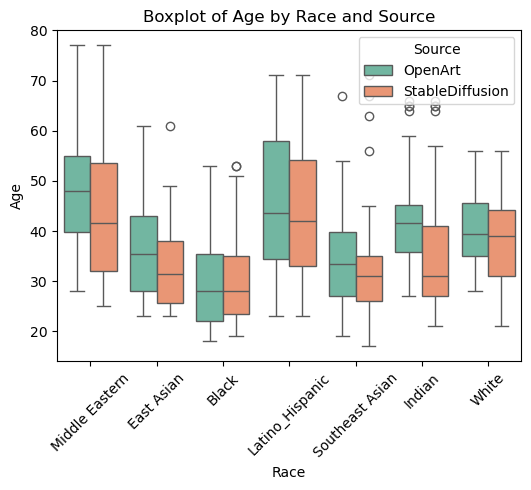

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取两个数据文件
file_path1 = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
file_path2 = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'

data1 = pd.read_csv(file_path1)
data2 = pd.read_csv(file_path2)

# 为每个数据框添加来源列
data1['Source'] = 'OpenArt'
data2['Source'] = 'StableDiffusion'

# 合并两个数据框
data = pd.concat([data1, data2], ignore_index=True)

# 定义要分析的评分列
score_columns = ['Age']

# 绘制箱线图
plt.figure(figsize=(15, 5))
for i, score_column in enumerate(score_columns):
    plt.subplot(1, 3, i + 1)  # 创建子图
    sns.boxplot(x='race', y=score_column, hue='Source', data=data, palette="Set2", dodge=True)
    plt.title(f'Boxplot of {score_column} by Race and Source')
    plt.xlabel('Race')
    plt.ylabel(score_column)
    plt.xticks(rotation=45)
    plt.legend(title='Source')

plt.tight_layout()
plt.show()

# 绘制小提琴图
# plt.figure(figsize=(15, 5))
# for i, score_column in enumerate(score_columns):
#     plt.subplot(1, 3, i + 1)  # 创建子图
#     sns.violinplot(x='race', y=score_column, hue='Source', data=data, inner='quartile', palette="Set2", split=True)
#     plt.title(f'Violin Plot of {score_column} by Race and Source')
#     plt.xlabel('Race')
#     plt.ylabel(score_column)
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()


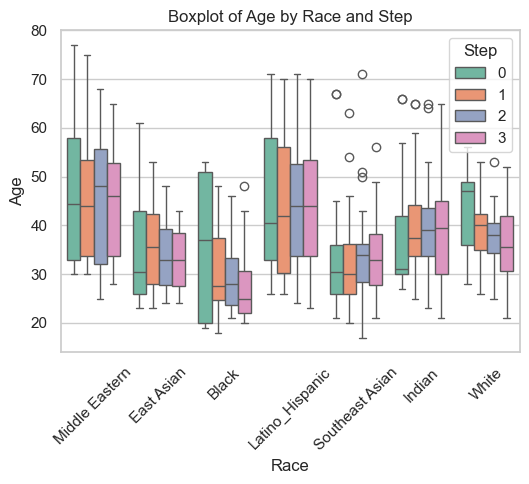

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 设置绘图风格
sns.set(style="whitegrid")

# 绘制箱线图
plt.figure(figsize=(15, 5))
for i, score_column in enumerate(score_columns):
    plt.subplot(1, 3, i + 1)  # 创建子图
    sns.boxplot(x='race', y=score_column, hue='Step', data=data, palette="Set2")
    plt.title(f'Boxplot of {score_column} by Race and Step')
    plt.xlabel('Race')
    plt.ylabel(score_column)
    plt.xticks(rotation=45)
    plt.legend(title='Step')

plt.tight_layout()
plt.show()

# 绘制小提琴图
# plt.figure(figsize=(15, 5))
# for i, score_column in enumerate(score_columns):
#     plt.subplot(1, 3, i + 1)  # 创建子图
#     sns.violinplot(x='race', y=score_column, hue='Step', data=data, inner='quartile', palette="Set2", split=True)
#     plt.title(f'Violin Plot of {score_column} by Race and Step')
#     plt.xlabel('Race')
#     plt.ylabel(score_column)
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()


In [5]:
#Open
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['Age']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")


Normality Test Results:
Age: W-statistic = 0.9670, p-value = 0.0000
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
Age: W-statistic = 3.3827, p-value = 0.0031
  -> 数据不满足方差齐性的假设。

Analyzing Age:
Kruskal-Wallis H Test Results: H-statistic = 60.8918, p-value = 0.0000
  -> 结果显著，说明不同种族之间的年龄存在差异。


In [7]:
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['Age']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 打印正态性检验结果
normality_df = pd.DataFrame(normality_results).T
print("Normality Test Results:")
print(normality_df)

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 打印方差齐性检验结果
levene_df = pd.DataFrame(levene_results).T
print("\nLevene's Test for Homogeneity of Variances Results:")
print(levene_df)

# 进行方差分析或Kruskal-Wallis H检验
results_summary = {}
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        results_summary[score_column] = {'Test': 'ANOVA', 'F-statistic': f_stat, 'p-value': p_value}
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    else:
        # Kruskal-Wallis H
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")

# 打印结果摘要
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)


Normality Test Results:
     W-statistic   p-value
Age     0.967031  0.000005

Levene's Test for Homogeneity of Variances Results:
     W-statistic   p-value
Age     3.382744  0.003106

Analyzing Age:
Kruskal-Wallis H Test Results: H-statistic = 60.8918, p-value = 0.0000

Statistical Test Results Summary:
    H-statistic              Test p-value
Age   60.891837  Kruskal-Wallis H     0.0


In [8]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_OpenB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['Age']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
    H-statistic              Test p-value
Age   60.891837  Kruskal-Wallis H     0.0

Dunn's Test Results for Age:
                        Black  East Asian    Indian  Latino_Hispanic  \
Black            1.000000e+00    0.024305  0.000001     1.500054e-07   
East Asian       2.430470e-02    1.000000  0.009949     2.697362e-03   
Indian           1.366276e-06    0.009949  1.000000     6.725210e-01   
Latino_Hispanic  1.500054e-07    0.002697  0.672521     1.000000e+00   
Middle Eastern   2.729293e-10    0.000049  0.137925     2.887487e-01   
Southeast Asian  1.054617e-01    0.526508  0.001323     2.794723e-04   
White            4.310877e-05    0.066081  0.459477     2.450733e-01   

                 Middle Eastern  Southeast Asian     White  
Black              2.729293e-10         0.105462  0.000043  
East Asian         4.883255e-05         0.526508  0.066081  
Indian             1.379253e-01         0.001323  0.459477  
Latino_Hispanic    2.887487e-0

In [6]:
#Stab
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['Age']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("Normality Test Results:")
for score_column, result in normality_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足正态分布的假设。")
    else:
        print("  -> 数据不满足正态分布的假设。")

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

print("\nLevene's Test for Homogeneity of Variances Results:")
for score_column, result in levene_results.items():
    print(f"{score_column}: W-statistic = {result['W-statistic']:.4f}, p-value = {result['p-value']:.4f}")
    if result['p-value'] > 0.05:
        print("  -> 数据满足方差齐性的假设。")
    else:
        print("  -> 数据不满足方差齐性的假设。")

# 根据正态性和方差齐性检验结果选择检验方法
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # 数据满足正态分布和方差齐性，使用 ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")
    else:
        # 数据不满足正态分布或方差齐性，使用 Kruskal-Wallis H 检验
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")
        if p_value < 0.05:
            print("  -> 结果显著，说明不同种族之间的年龄存在差异。")
        else:
            print("  -> 结果不显著，说明不同种族之间的年龄不存在显著差异。")


Normality Test Results:
Age: W-statistic = 0.9195, p-value = 0.0000
  -> 数据不满足正态分布的假设。

Levene's Test for Homogeneity of Variances Results:
Age: W-statistic = 3.7708, p-value = 0.0013
  -> 数据不满足方差齐性的假设。

Analyzing Age:
Kruskal-Wallis H Test Results: H-statistic = 43.5270, p-value = 0.0000
  -> 结果显著，说明不同种族之间的年龄存在差异。


In [9]:
#Stab
import pandas as pd
import scipy.stats as stats

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['Age']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 打印正态性检验结果
normality_df = pd.DataFrame(normality_results).T
print("Normality Test Results:")
print(normality_df)

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 打印方差齐性检验结果
levene_df = pd.DataFrame(levene_results).T
print("\nLevene's Test for Homogeneity of Variances Results:")
print(levene_df)

# 进行方差分析或Kruskal-Wallis H检验
results_summary = {}
for score_column in score_columns:
    normality_p = normality_results[score_column]['p-value']
    levene_p = levene_results[score_column]['p-value']

    print(f"\nAnalyzing {score_column}:")
    if normality_p > 0.05 and levene_p > 0.05:
        # ANOVA
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        f_stat, p_value = stats.f_oneway(*grouped_data)
        results_summary[score_column] = {'Test': 'ANOVA', 'F-statistic': f_stat, 'p-value': p_value}
        print(f"ANOVA Results: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    else:
        # Kruskal-Wallis H
        grouped_data = [group[score_column].values for name, group in data.groupby('race')]
        h_stat, p_value = stats.kruskal(*grouped_data)
        results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}
        print(f"Kruskal-Wallis H Test Results: H-statistic = {h_stat:.4f}, p-value = {p_value:.4f}")

# 打印结果摘要
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)


Normality Test Results:
     W-statistic       p-value
Age     0.919485  3.844722e-11

Levene's Test for Homogeneity of Variances Results:
     W-statistic   p-value
Age     3.770791  0.001266

Analyzing Age:
Kruskal-Wallis H Test Results: H-statistic = 43.5270, p-value = 0.0000

Statistical Test Results Summary:
    H-statistic              Test p-value
Age    43.52701  Kruskal-Wallis H     0.0


In [10]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 读取数据文件
file_path = r'd:\Users\AAA\Desktop\face++\Filter_StabB.csv'
data = pd.read_csv(file_path)

# 定义要分析的评分列
score_columns = ['Age']

# 进行正态性检验
normality_results = {}
for score_column in score_columns:
    stat, p_value = stats.shapiro(data[score_column])
    normality_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 进行方差齐性检验
levene_results = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    stat, p_value = stats.levene(*grouped_data)
    levene_results[score_column] = {'W-statistic': stat, 'p-value': p_value}

# 结果汇总
results_summary = {}
post_hoc_results = []

# 进行Kruskal-Wallis H检验
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    h_stat, p_value = stats.kruskal(*grouped_data)
    results_summary[score_column] = {'Test': 'Kruskal-Wallis H', 'H-statistic': h_stat, 'p-value': p_value}

    if p_value < 0.05:
        # 进行Dunn's检验以确定具体差异
        from scikit_posthocs import posthoc_dunn
        dunn_results = posthoc_dunn(data, val_col=score_column, group_col='race')
        post_hoc_results.append((score_column, dunn_results))

# 打印结果汇总
results_df = pd.DataFrame(results_summary).T
print("\nStatistical Test Results Summary:")
print(results_df)

# 打印Dunn's检验结果
for score_column, dunn_results in post_hoc_results:
    print(f"\nDunn's Test Results for {score_column}:")
    print(dunn_results)

# 效应量计算
def eta_squared(anova_table):
    """计算Eta squared效应量"""
    return anova_table['sum_sq'][0] / (anova_table['sum_sq'][0] + anova_table['sum_sq'][1])

# 效应量计算
effect_sizes = {}
for score_column in score_columns:
    grouped_data = [group[score_column].values for name, group in data.groupby('race')]
    n_total = len(data[score_column])
    n_groups = len(grouped_data)

    # 计算H-statistic
    h_stat, _ = stats.kruskal(*grouped_data)

    # 计算Eta squared
    eta_sq = h_stat / (n_total - 1)
    effect_sizes[score_column] = eta_sq

# 效应量结果
effect_sizes_df = pd.DataFrame(effect_sizes, index=["Eta squared"])
print("\nEffect Sizes Summary:")
print(effect_sizes_df)



Statistical Test Results Summary:
    H-statistic              Test p-value
Age    43.52701  Kruskal-Wallis H     0.0

Dunn's Test Results for Age:
                    Black  East Asian    Indian  Latino_Hispanic  \
Black            1.000000    0.353552  0.076075         0.000011   
East Asian       0.353552    1.000000  0.397436         0.000525   
Indian           0.076075    0.397436  1.000000         0.008754   
Latino_Hispanic  0.000011    0.000525  0.008754         1.000000   
Middle Eastern   0.000002    0.000123  0.002761         0.710160   
Southeast Asian  0.450648    0.862348  0.307920         0.000271   
White            0.000460    0.010017  0.083804         0.372129   

                 Middle Eastern  Southeast Asian     White  
Black                  0.000002         0.450648  0.000460  
East Asian             0.000123         0.862348  0.010017  
Indian                 0.002761         0.307920  0.083804  
Latino_Hispanic        0.710160         0.000271  0.372129  
M

In [8]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''
    新版
    统计分析：线性混合效应模型
'''
file_path1=r'd:\Users\AAA\Desktop\face++\OpenB.csv'
file_path2=r'd:\Users\AAA\Desktop\face++\StabB.csv'
# 读取数据
df = pd.read_csv(file_path1)
sf = pd.read_csv(file_path2)

jiaocha="+ Language_ar * Step + Language_zh * Step + Language_es * Step + Language_id * Step + Language_hi * Step+ Language_AAE * Step + Gender * Step"
# 定义线性混合效应模型
model = mixedlm("Age ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE  + Gender ", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model2 = mixedlm("Age ~ Language_ar + Language_zh + Language_es + Language_id + Language_hi + Language_AAE + Gender ", 
                sf, 
                groups=sf["Group"])
# 拟合模型
result = model.fit()
result2= model2.fit()
# 打印结果
print("OpenArt年龄",result.summary())
print("StableDiffusion年龄",result2.summary())

OpenArt年龄          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Age       
No. Observations: 1540    Method:             REML      
No. Groups:       70      Scale:              33.7332   
Min. group size:  22      Log-Likelihood:     -5033.5869
Max. group size:  22      Converged:          Yes       
Mean group size:  22.0                                  
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept    37.879    1.269  29.850 0.000 35.392 40.367
Language_ar   6.021    0.533  11.291 0.000  4.975  7.066
Language_zh   6.352    0.531  11.955 0.000  5.311  7.393
Language_es   4.297    0.530   8.103 0.000  3.257  5.336
Language_id   0.482    0.533   0.904 0.366 -0.563  1.526
Language_hi   9.027    0.545  16.576 0.000  7.959 10.094
Language_AAE -6.027    0.530 -11.366 0.000 -7.066 -4.988
Gender       -1.202    0.673  -

Step              0          1          2          3
Language                                            
AAE       40.142857  33.357143  31.685714  28.728571
SAE       40.142857  35.971429  36.571429  36.514286
ar        40.142857  42.700000  44.400000  42.557143
es        40.142857  40.457143  42.957143  41.328571
hi        40.142857  46.571429  45.957143  45.785714
id        40.142857  36.385714  38.971429  37.700000
zh        40.142857  44.085714  43.757143  42.928571


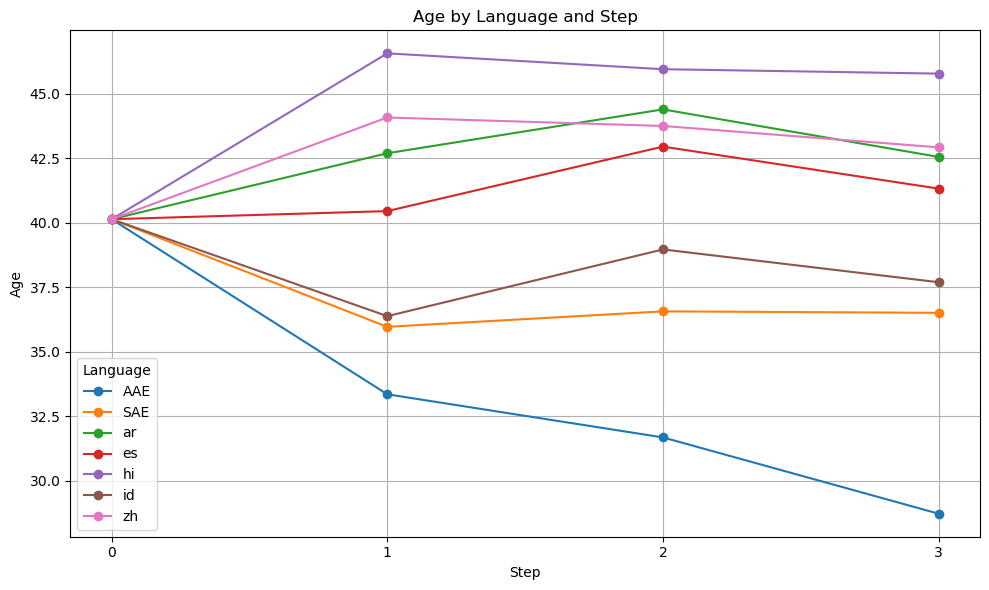

count    1540.000000
mean       39.977922
std        12.108650
min        12.000000
25%        30.000000
50%        39.500000
75%        49.000000
max        77.000000
Name: Age, dtype: float64


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
'''
    新版折线图
'''
# 文件路径
file_path = r'd:\Users\AAA\Desktop\face++\OpenB.csv'

# 读取数据
df = pd.read_csv(file_path)

# 创建一个新的 DataFrame 存储结果
results = pd.DataFrame()

# 计算递进层次为0的平均颜值分数
age_0 = df[df['Step'] == 0]['Age'].mean()

# 创建包含所有语言的初始行
languages = ['ar', 'zh', 'SAE', 'es', 'id', 'hi','AAE']
initial_rows = pd.DataFrame({'Language': languages, 'Age': age_0, 'Step': 0})

# 将初始行添加到结果 DataFrame 中
results = pd.concat([results, initial_rows], ignore_index=True)

# 按语言和递进层次计算平均颜值分数
for lang in ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi','Language_AAE']:
    age = df[df[lang] == 1].groupby('Step')['Age'].mean().reset_index()
    age['Language'] = lang.split('_')[1]  # 提取语言名
    age = age.rename(columns={'age': 'Age'})  # 重命名列
    results = pd.concat([results, age], ignore_index=True)

# 确保结果的列名一致
results.columns = ['Language', 'Age', 'Step']

# 用 pivot 展示结果
pivot_table = results.pivot(index='Language', columns='Step', values='Age')

# 输出表格
print(pivot_table)

# 绘制结果折线图
plt.figure(figsize=(10, 6))
for lang in pivot_table.index:
    plt.plot(pivot_table.columns, pivot_table.loc[lang], marker='o', label=lang)

plt.title('Age by Language and Step')
plt.xlabel('Step')
plt.ylabel('Age')
plt.xticks([0,1,2,3])
plt.legend(title='Language')
plt.tight_layout()
plt.grid()
plt.show()

'''描述性统计'''

# 描述性统计
descriptive_stats = df['Age'].describe()

# 打印描述性统计结果
print(descriptive_stats)

Step              0          1          2          3
Language                                            
AAE       40.142857  36.057143  33.385714  30.142857
SAE       40.142857  36.985714  35.085714  33.500000
ar        40.142857  39.042857  38.714286  39.485714
es        40.142857  39.271429  39.071429  41.471429
hi        40.142857  38.871429  37.542857  36.185714
id        40.142857  37.414286  35.685714  35.414286
zh        40.142857  39.171429  36.928571  36.514286


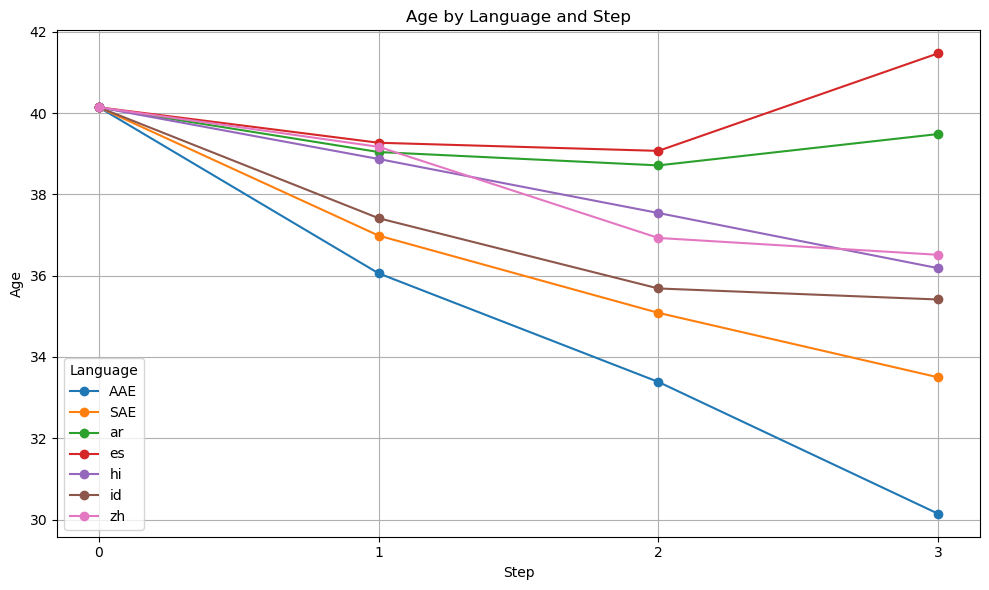

count    1540.000000
mean       37.094805
std        12.241244
min         9.000000
25%        27.000000
50%        34.000000
75%        45.000000
max        77.000000
Name: Age, dtype: float64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
'''
    新版折线图
'''
# 文件路径
file_path = r'd:\Users\AAA\Desktop\face++\StabB.csv'

# 读取数据
df = pd.read_csv(file_path)

# 创建一个新的 DataFrame 存储结果
results = pd.DataFrame()

# 计算递进层次为0的平均颜值分数
age_0 = df[df['Step'] == 0]['Age'].mean()

# 创建包含所有语言的初始行
languages = ['ar', 'zh', 'SAE', 'es', 'id', 'hi','AAE']
initial_rows = pd.DataFrame({'Language': languages, 'Age': age_0, 'Step': 0})

# 将初始行添加到结果 DataFrame 中
results = pd.concat([results, initial_rows], ignore_index=True)

# 按语言和递进层次计算平均颜值分数
for lang in ['Language_ar', 'Language_zh', 'Language_SAE', 'Language_es', 'Language_id', 'Language_hi','Language_AAE']:
    age = df[df[lang] == 1].groupby('Step')['Age'].mean().reset_index()
    age['Language'] = lang.split('_')[1]  # 提取语言名
    age = age.rename(columns={'age': 'Age'})  # 重命名列
    results = pd.concat([results, age], ignore_index=True)

# 确保结果的列名一致
results.columns = ['Language', 'Age', 'Step']

# 用 pivot 展示结果
pivot_table = results.pivot(index='Language', columns='Step', values='Age')

# 输出表格
print(pivot_table)

# 绘制结果折线图
plt.figure(figsize=(10, 6))
for lang in pivot_table.index:
    plt.plot(pivot_table.columns, pivot_table.loc[lang], marker='o', label=lang)

plt.title('Age by Language and Step')
plt.xlabel('Step')
plt.ylabel('Age')
plt.xticks([0,1,2,3])
plt.legend(title='Language')
plt.tight_layout()
plt.grid()
plt.show()

'''描述性统计'''

# 描述性统计
descriptive_stats = df['Age'].describe()

# 打印描述性统计结果
print(descriptive_stats)

In [6]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
'''统计分析：线性混合效应模型'''
file_path1=r'd:\Users\AAA\Desktop\face++\OpenA.csv'
file_path2=r'd:\Users\AAA\Desktop\face++\StabA.csv'
# 读取数据
df = pd.read_csv(file_path1)
sf = pd.read_csv(file_path2)
# 定义线性混合效应模型
model = mixedlm("Age ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step + Language_al * Step + Language_cn * Step + Language_sp * Step + Language_yn * Step + Language_yd * Step + Gender * Step", 
                df, 
                groups=df["Group"])
# 定义线性混合效应模型
model2 = mixedlm("Age ~ Language_al + Language_cn + Language_sp + Language_yn + Language_yd + Gender + Step", 
                sf, 
                groups=df["Group"])
# 拟合模型
result = model.fit()
result2= model2.fit()
# 打印结果
print("OpenArt年龄",result.summary())
print("StableDiffusion年龄",result2.summary())

OpenArt年龄            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Age       
No. Observations:   1330     Method:              REML      
No. Groups:         70       Scale:               30.2128   
Min. group size:    19       Log-Likelihood:      -4290.4473
Max. group size:    19       Converged:           Yes       
Mean group size:    19.0                                    
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         39.955    1.423 28.077 0.000 37.166 42.744
Language_al        4.435    1.145  3.871 0.000  2.190  6.680
Language_cn        5.908    1.144  5.163 0.000  3.665  8.150
Language_sp        1.820    1.145  1.591 0.112 -0.423  4.064
Language_yn       -2.357    1.146 -2.057 0.040 -4.603 -0.111
Language_yd        8.261    1.148  7.193 0.000  6.010 10.512
Gender            -2.053  